# YOLO实操教程

本章通过样例数据集演示如何在ultralytics项目中，实现YOLO模型训练及推理。  
其中采用的数据集为下采样的DOTAv1，模型采用yolov11-obb，实现旋转目标检测。  

注：本文档为初学者提供jupyter notebook形式代码演示，完整项目结构参考对应的py文件


# 一、数据集类别裁剪
对DOTAv1 数据集进行类别裁剪，选择需要训练的类别，重新生成数据集

首先通过[链接](https://github.com/ultralytics/assets/releases/download/v0.0.0/DOTAv1.zip)下载DOTAv1数据集，解压得到如下内容：
```python
.
├── images
│   ├── test
│   ├── train
│   └── val
└── labels
    ├── train
    ├── train_original
    ├── val
    └── val_original

通用函数

In [1]:
# 导入通用函数
from utils_exp import *
import matplotlib.pyplot as plt
%matplotlib inline

## 下载数据

In [ ]:
# 原始数据路径
# 下载改文件并解压到指定目录： 

# !wget https://github.com/ultralytics/assets/releases/download/v0.0.0/DOTAv1.zip
# !unzip -o DOTAv1.zip

In [ ]:
data_dir = r"./DOTAv1"  # 配置你的数据集所在路径 !!!
data_dir_sub = os.path.join(data_dir, "DOTA-sub")  # 输出目录

In [7]:
# 需要保留的类别及其新映射
keep_classes_l = [0, 1]  # 挑选的类别，这里选择第0类和第1类。
keep_classes = {ori_class_idx: trg_index for trg_index, ori_class_idx in enumerate(keep_classes_l)}

cut_data(data_dir, data_dir_sub, keep_classes, setname='val')
cut_data(data_dir, data_dir_sub, keep_classes, setname='train')

筛选和映射完成！获得174张图片，位于:G:\deep_learning_data\DOTAv1\DOTA-sub
筛选和映射完成！获得516张图片，位于:G:\deep_learning_data\DOTAv1\DOTA-sub


查看一下数据情况

In [42]:
# 原始DOTAv1
print_yolo_dataset_info(data_dir)
# 裁剪后DOTA
print("*"*30)
print_yolo_dataset_info(data_dir_sub)

数据集G:\deep_learning_data\DOTAv1基本信息：
训练集图片数量: 1411
验证集图片数量: 458
总图片数量: 1869
训练集标签数量: 1411
验证集标签数量: 458
总标签数量: 1869
类别数量: 15
类别分布：
  类别 0: 10586 个实例
  类别 1: 37028 个实例
  类别 2: 7917 个实例
  类别 3: 629 个实例
  类别 4: 3127 个实例
  类别 5: 647 个实例
  类别 6: 469 个实例
  类别 7: 8073 个实例
  类别 8: 2511 个实例
  类别 9: 21356 个实例
  类别 10: 31564 个实例
  类别 11: 703 个实例
  类别 12: 578 个实例
  类别 13: 479 个实例
  类别 14: 2176 个实例
******************************
数据集G:\deep_learning_data\DOTAv1\DOTA-sub基本信息：
训练集图片数量: 516
验证集图片数量: 174
总图片数量: 690
训练集标签数量: 516
验证集标签数量: 174
总标签数量: 690
类别数量: 2
类别分布：
  类别 0: 10586 个实例
  类别 1: 37028 个实例


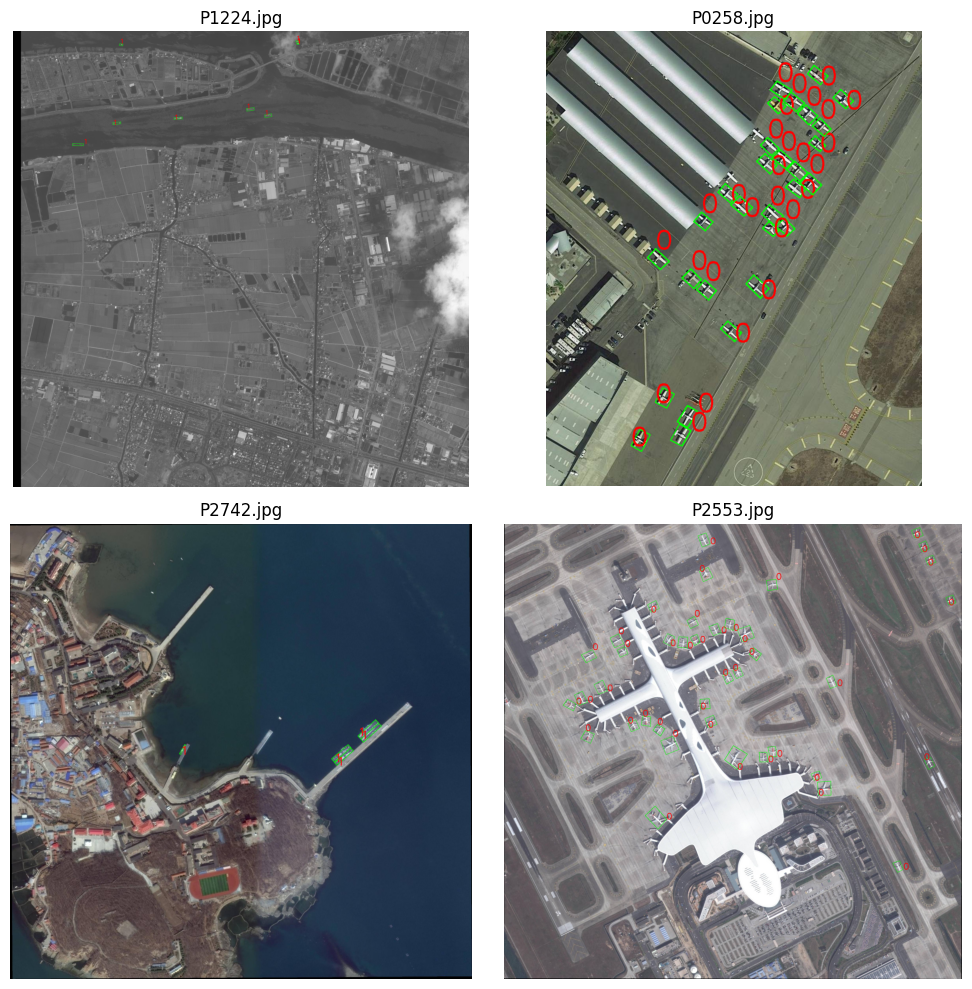

In [68]:
# 可视化随机N张图像
visualize_random_images(data_dir_sub, setname='train', num_images=4)

# 二、图片切块
由于DOTAv1的图片分辨率从 800x800 到 4000x4000 不等，直接输入给YOLO模型，会导致目标过小，难以检测。若提高图像分辨率，对计算也带来挑战。  
为此，对于DOTA数据常用的操作是对原图进行切块，切为多个小图像块再进行目标检测模型训练。 

In [44]:
import os
from ultralytics.data.split_dota import split_test, split_trainval

data_dir_sub_split = os.path.join(os.path.dirname(data_dir_sub), 'DOTA-sub-split')  # data_dir_sub 是类别裁剪得到的目录

# 对数据集图片进行切块处理，降低图片尺寸
print(f"从{data_dir_sub}切块，保存到:{data_dir_sub_split}")
split_trainval(data_root=data_dir_sub, save_dir=data_dir_sub_split, rates=[1.0], crop_size=640, gap=50)  # gap表示重叠的像素


从G:\deep_learning_data\DOTAv1\DOTA-sub切块，保存到:G:\deep_learning_data\DOTAv1\DOTA-sub-split


val: 100%|███████████████████████████████████████████████████████████████████████████| 174/174 [00:56<00:00,  3.08it/s]


数据已保存到: G:\deep_learning_data\DOTAv1\DOTA-sub-split
数据集G:\deep_learning_data\DOTAv1\DOTA-sub-split基本信息：
训练集图片数量: 16677
验证集图片数量: 5578
总图片数量: 22255
训练集标签数量: 4692
验证集标签数量: 1438
总标签数量: 6130
类别数量: 2
类别分布：
  类别 0: 12932 个实例
  类别 1: 53597 个实例


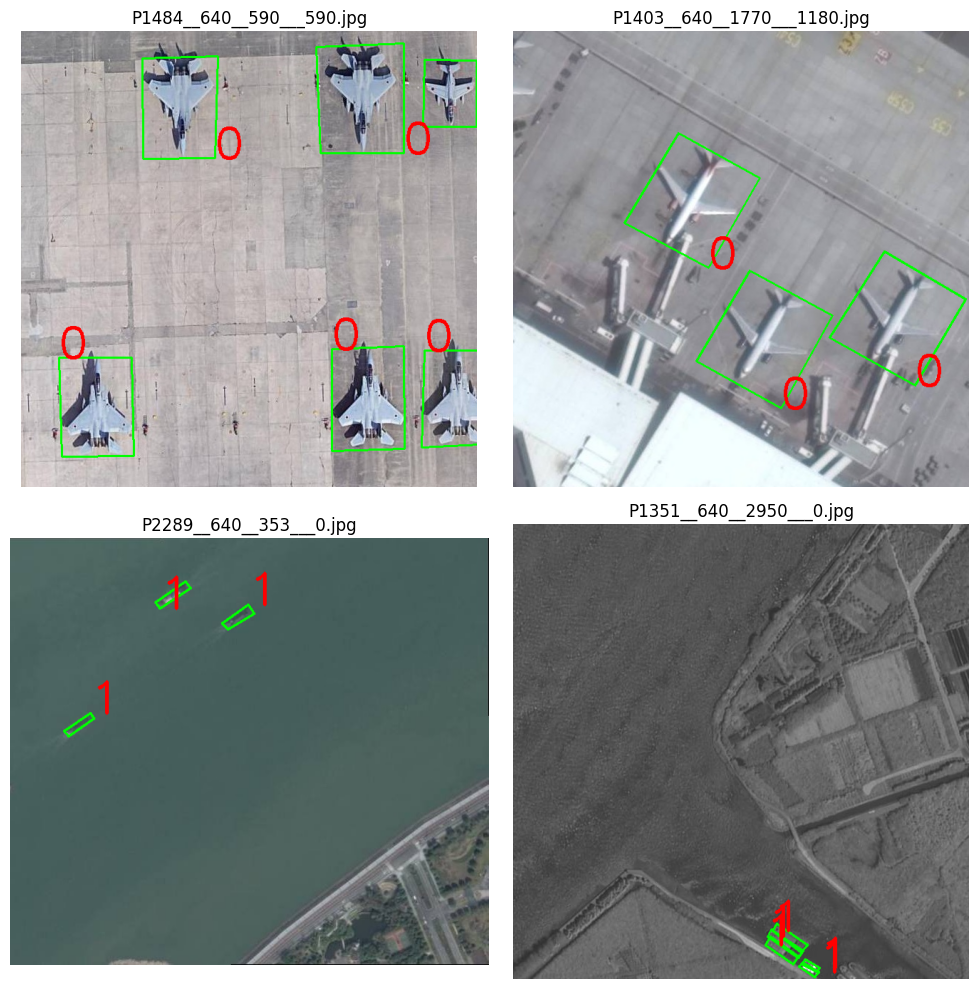

In [71]:
print(f"数据已保存到: {data_dir_sub_split}")
print_yolo_dataset_info(data_dir_sub_split)
visualize_random_images(data_dir_sub_split, setname='train', num_images=4)  # 可视化随机N张图像

# 三、图片下采样

由于上万的图片训练需要较长的时间，因此可以再次挑选其中一部分图片进行构建最终的数据集。  
运行代码，设置比例为10%，可以获得469张训练图片，143张验证图片，这将构成后续训练模型的数据。

In [61]:
import shutil
import random
from tqdm import tqdm

random.seed(42)

new_data_root = data_dir_sub_split + '-downsample'  # data_dir_sub_split 是上一步得到的文件目录
data_root = data_dir_sub_split

if os.path.exists(new_data_root):
    shutil.rmtree(new_data_root)

# 采样比例
sampling_ratio = 0.1

# 处理 train 和 val 目录
for split in ['train', 'val']:
    # 原始图片和标签路径
    split_image_dir = os.path.join(data_root, 'images', split)
    split_label_dir = os.path.join(data_root, 'labels', split)

    # 新图片和标签路径
    new_split_image_dir = os.path.join(new_data_root, 'images', split)
    new_split_label_dir = os.path.join(new_data_root, 'labels', split)
    os.makedirs(new_split_image_dir, exist_ok=True)
    os.makedirs(new_split_label_dir, exist_ok=True)

    # 获取当前 split 的所有图片文件
    label_files = [f for f in os.listdir(split_label_dir) if f.endswith(('.txt'))]
    random.shuffle(label_files)  # 随机打乱顺序

    # 计算需要采样的数量
    sample_size = int(len(label_files) * sampling_ratio)
    sampled_files = label_files[:sample_size]  # 取前10%

    # 复制采样后的图片和标签文件到新目录
    for label_file in tqdm(sampled_files):
        # 复制图片
        image_file = label_file.replace('txt', 'jpg')

        original_image_path = os.path.join(split_image_dir, image_file)
        new_image_path = os.path.join(new_split_image_dir, image_file)
        shutil.copy(original_image_path, new_image_path)

        # 复制对应的标签文件
        original_label_path = os.path.join(split_label_dir, label_file)
        new_label_path = os.path.join(new_split_label_dir, label_file)

        if os.path.exists(original_label_path):
            shutil.copy(original_label_path, new_label_path)
    print(f"{split} 下采样完成！共采样 {len(sampled_files)} 张图片和标签文件。")

100%|███████████████████████████████████████████████████████████████████████████████| 469/469 [00:01<00:00, 384.07it/s]


train 下采样完成！共采样 469 张图片和标签文件。


100%|███████████████████████████████████████████████████████████████████████████████| 143/143 [00:00<00:00, 367.77it/s]

val 下采样完成！共采样 143 张图片和标签文件。


数据集G:\deep_learning_data\DOTAv1\DOTA-sub-split-downsample基本信息：
训练集图片数量: 469
验证集图片数量: 143
总图片数量: 612
训练集标签数量: 469
验证集标签数量: 143
总标签数量: 612
类别数量: 2
类别分布：
  类别 0: 1147 个实例
  类别 1: 4955 个实例


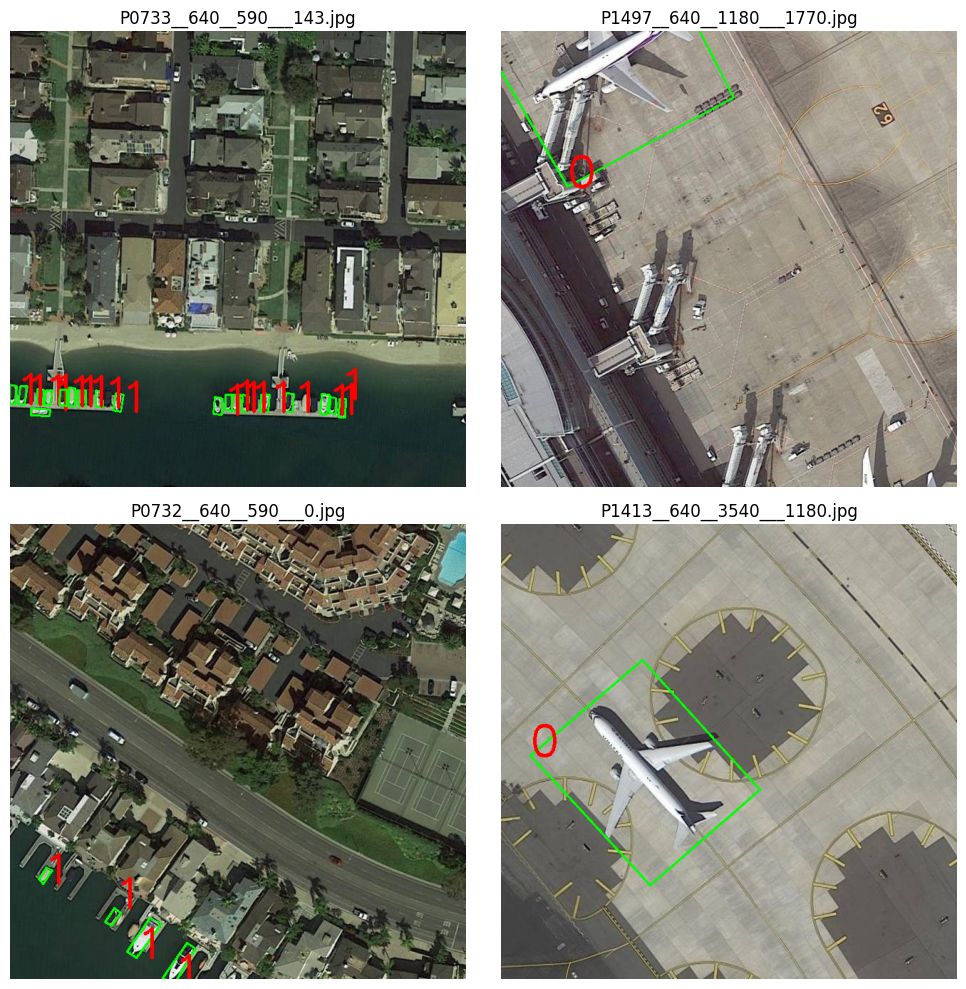

In [70]:
print_yolo_dataset_info(new_data_root)
visualize_random_images(new_data_root, setname='train', num_images=4)  # 随机可视化4张图片

# 四、数据可视化
由于做了太多的处理，在训练前有必要对数据集进行可视化检查，运行代码可以得到标签可视化结果。

In [72]:
print(new_data_root)

G:\deep_learning_data\DOTAv1\DOTA-sub-split-downsample


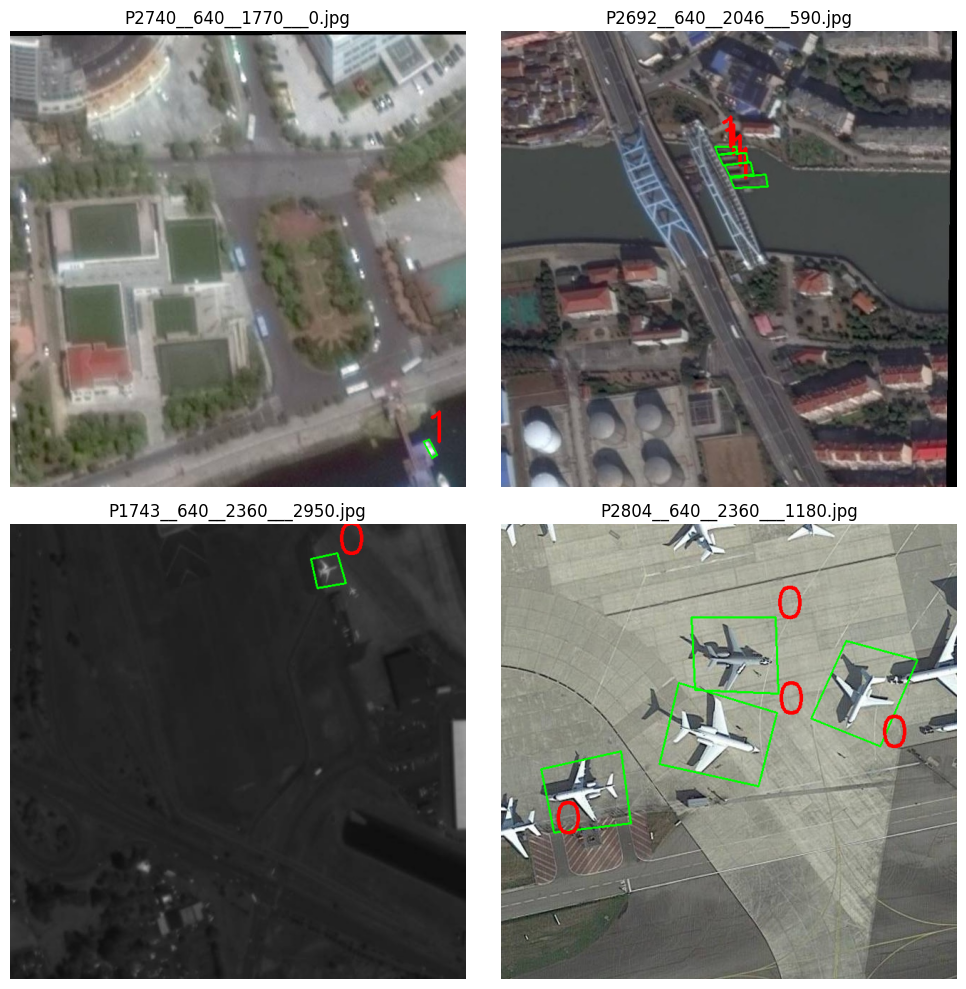

In [73]:
# 可视化随机N张图像
visualize_random_images(new_data_root, setname='train', num_images=4)

# 五、模型训练

## 特别注意事项！重要！

由于ultralytics旋转目标检测的代码问题，在训练中的验证代码里的NMS可能导致显存激增导致程序终止，这块目前没有好的方法，建议大家修改max_nms数量来避免。
详情可参考[issue](https://github.com/ultralytics/ultralytics/issues/7636)

具体操作：
1. 首先找到ultralytics的安装目录，然后找到对应的.py文件：ultralytics/models/yolo/detect/val.py。   
2. 对于ops.non_max_suppression函数，新增一个入参(默认值为30000)，max_nms=1920（ops文件路径 ./site-packages/ultralytics/utils/ops.py）。
```python
    def postprocess(self, preds: torch.Tensor) -> List[Dict[str, torch.Tensor]]:
        """
        Apply Non-maximum suppression to prediction outputs.

        Args:
            preds (torch.Tensor): Raw predictions from the model.

        Returns:
            (List[Dict[str, torch.Tensor]]): Processed predictions after NMS, where each dict contains
                'bboxes', 'conf', 'cls', and 'extra' tensors.
        """
        outputs = ops.non_max_suppression(
            preds,
            self.args.conf,
            self.args.iou,
            nc=0 if self.args.task == "detect" else self.nc,
            multi_label=True,
            agnostic=self.args.single_cls or self.args.agnostic_nms,
            max_det=self.args.max_det,
            max_nms=1920,  # <= Monkey patch here
            end2end=self.end2end,
            rotated=self.args.task == "obb",
        )
        return [{"bboxes": x[:, :4], "conf": x[:, 4], "cls": x[:, 5], "extra": x[:, 6:]} for x in outputs]

```


In [2]:
import ultralytics
install_dir = os.path.dirname(ultralytics.__file__)
val_path = os.path.join(install_dir, "models", 'yolo', 'detect', 'val.py')
print(f"ultralytics 安装目录: {install_dir} \n所需修改的文件路径:{val_path}")

ultralytics 安装目录: /home/cine/anaconda3/envs/yolo/lib/python3.10/site-packages/ultralytics 
所需修改的文件路径:/home/cine/anaconda3/envs/yolo/lib/python3.10/site-packages/ultralytics/models/yolo/detect/val.py


In [100]:
import os
from ultralytics import YOLO
BASE_DIR = os.getcwd()

# 路径配置
dataset_path = os.path.join(BASE_DIR, 'cfg', 'DOTAv1-sub.yaml')  # 数据集
check_yolo_yaml_paths(dataset_path)  # 注意！训练前请修改数据集yaml配置文件中的根目录
yolo11n_obb_path = os.path.join(BASE_DIR, 'cfg', 'yolo11s-obb.yaml')  # 模型

In [103]:
# Load a model
model = YOLO(yolo11n_obb_path)

# Train the model
results = model.train(data=dataset_path, epochs=50, amp=False, batch=8)

Ultralytics 8.3.54  Python-3.10.14 torch-2.2.0 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: task=obb, mode=train, model=D:\github_desktop\yolo_master\code\exp-DOTA-obb\cfg\yolo11s-obb.yaml, data=D:\github_desktop\yolo_master\code\exp-DOTA-obb\cfg\DOTAv1-sub.yaml, epochs=50, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train9, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=False, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False

train: Scanning G:\deep_learning_data\DOTAv1\DOTA-sub-split-downsample\labels\train... 469 images, 0 backgrounds, 1 cor

train: WARNING  G:\deep_learning_data\DOTAv1\DOTA-sub-split-downsample\images\train\P2641__640__4130___4985.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.3063]
train: New cache created: G:\deep_learning_data\DOTAv1\DOTA-sub-split-downsample\labels\train.cache



val: Scanning G:\deep_learning_data\DOTAv1\DOTA-sub-split-downsample\labels\val... 143 images, 0 backgrounds, 0 corrupt

val: New cache created: G:\deep_learning_data\DOTAv1\DOTA-sub-split-downsample\labels\val.cache


...

      50/50       4.4G      1.304     0.9699      1.931         12        640: 100%|██████████| 59/59 [00:11<00:00,  5.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:02

                   all        143       1699      0.862      0.869      0.912      0.661



50 epochs completed in 0.215 hours.
Optimizer stripped from runs\obb\train9\weights\last.pt, 20.0MB
Optimizer stripped from runs\obb\train9\weights\best.pt, 20.0MB

Validating runs\obb\train9\weights\best.pt...
Ultralytics 8.3.54  Python-3.10.14 torch-2.2.0 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11s-obb summary (fused): 257 layers, 9,699,561 parameters, 0 gradients, 22.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:03


                   all        143       1699      0.876      0.863      0.913      0.666
                 plane         66        270      0.899       0.89       0.93      0.719
                  ship         77       1429      0.854      0.836      0.895      0.612
Speed: 0.5ms preprocess, 7.2ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to runs\obb\train9


查看训练日志信息

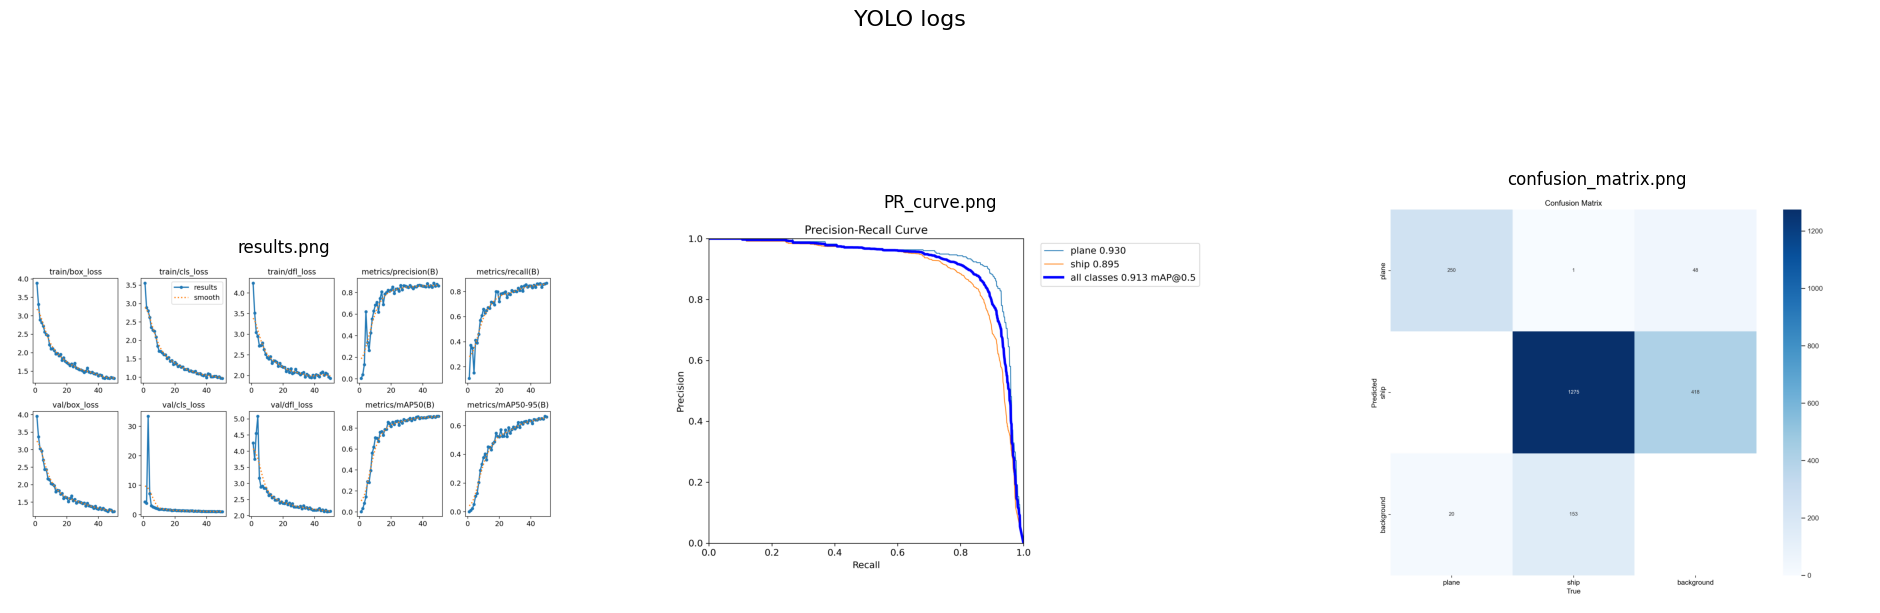

In [114]:
log_dir = results.save_dir
visualize_yolo_logs(log_dir)

# 六、模型评估

In [115]:
dataset_path = os.path.join(BASE_DIR, 'cfg', 'DOTAv1-sub.yaml')  # 数据集

# weights_path = os.path.join(BASE_DIR, 'runs', 'obb', 'train9', 'weights', 'best.pt')  # 模型，手动写路径
weights_path = os.path.join(results.save_dir,  'weights', 'best.pt')  # 模型

model = YOLO(weights_path)
metrics_val = model.val(data=dataset_path, imgsz=640, batch=16, conf=0.25, iou=0.6)

Ultralytics 8.3.54  Python-3.10.14 torch-2.2.0 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11s-obb summary (fused): 257 layers, 9,699,561 parameters, 0 gradients, 22.3 GFLOPs


val: Scanning G:\deep_learning_data\DOTAv1\DOTA-sub-split-downsample\labels\val.cache... 143 images, 0 backgrounds, 0 c
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:05<0


                   all        143       1699      0.882      0.867      0.913      0.695
                 plane         66        270      0.899      0.892      0.929      0.745
                  ship         77       1429      0.865      0.841      0.897      0.644
Speed: 1.1ms preprocess, 9.0ms inference, 0.0ms loss, 4.1ms postprocess per image
Results saved to runs\obb\val6


ultralytics.utils.metrics.OBBMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000021F0C5B9180>
curves: []
curves_results: []
fitness: 0.7164214599572207
keys: ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']
maps: array([    0.74493,     0.64427])
names: {0: 'plane', 1: 'ship'}
plot: True
results_dict: {'metrics/precision(B)': 0.8820875150558731, 'metrics/recall(B)': 0.8665417741196145, 'metrics/mAP50(B)': 0.9127824809858328, 'metrics/mAP50-95(B)': 0.6946035687318193, 'fitness': 0.7164214599572207}
save_dir: WindowsPath('runs/obb/val6')
speed: {'preprocess': 1.147390245557665, 'inference': 8.99804555452787, 'loss': 0.027975002368846973, 'postprocess': 4.085665816193694}


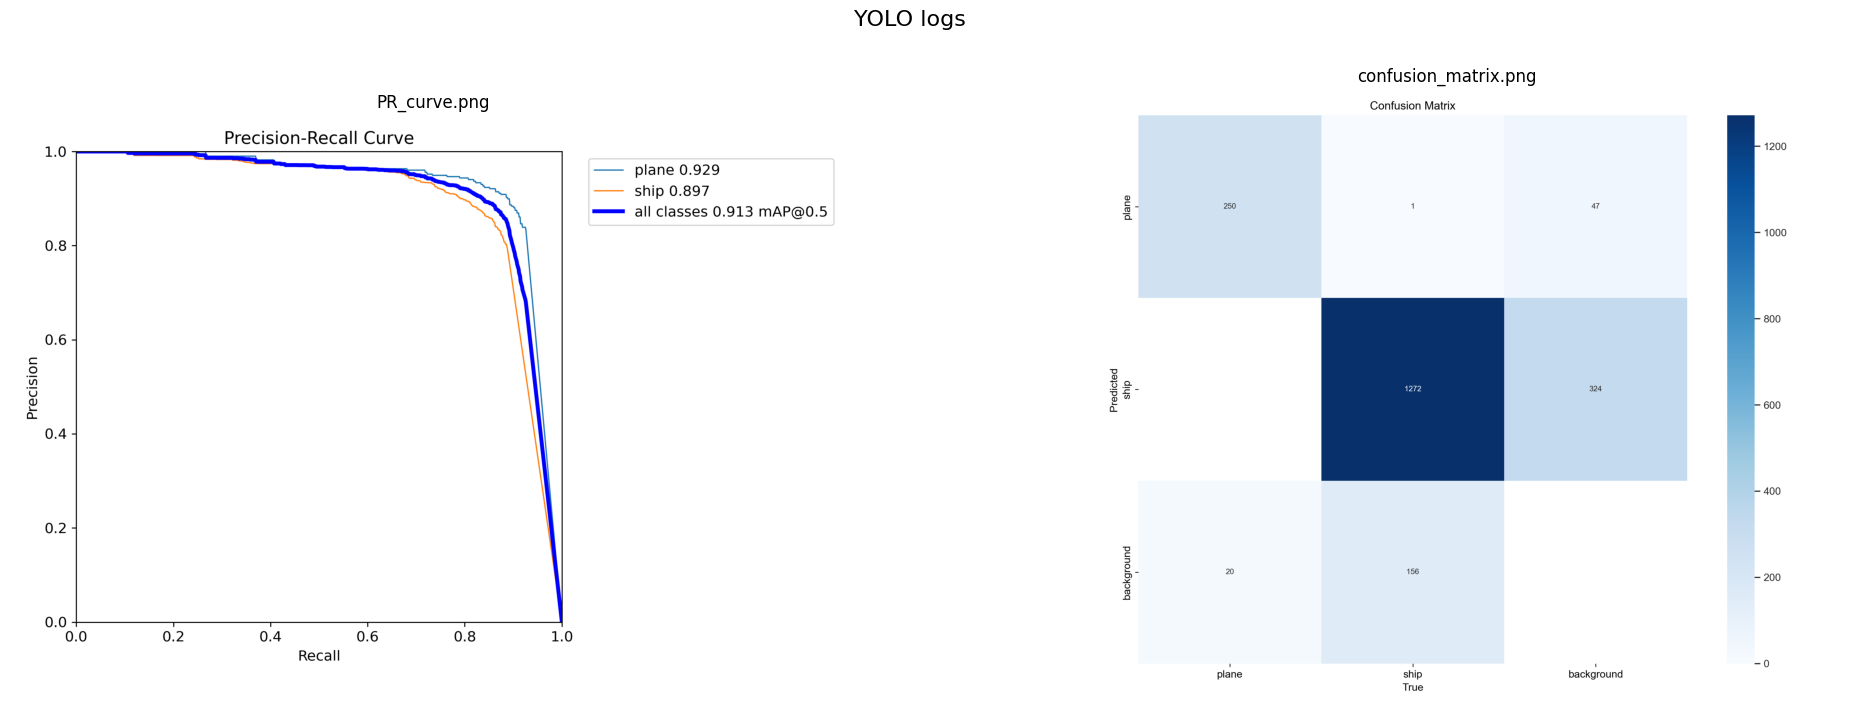

In [122]:
print(metrics_val)
visualize_yolo_logs(metrics_val.save_dir, 'val')

# 七、模型推理


image 1/1 G:\deep_learning_data\DOTAv1\DOTA-sub-split-downsample\images\val\P2231__640__590___1180.jpg: 1024x1024 44.0ms
Speed: 16.0ms preprocess, 44.0ms inference, 4.0ms postprocess per image at shape (1, 3, 1024, 1024)
[     466.16      438.61      62.214      58.886     0.19162]
xywhr转换后得到四个顶点： [[430 461]
 [441 403]
 [502 415]
 [491 473]]


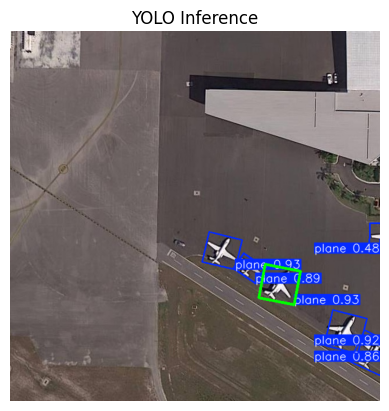

In [ ]:
import cv2
import numpy as np
import os
from ultralytics import YOLO
import matplotlib.pyplot as plt
%matplotlib inline
BASE_DIR = os.getcwd()


# 路径配置
weights_path = os.path.join(BASE_DIR, 'runs', 'obb', 'train', 'weights', 'best.pt')  
image_path = r"./DOTAv1/DOTA-sub-split-downsample/images/val/P2231__640__590___1180.jpg" 

# ========================== step1: 初始化YOLO对象 ==========================
model = YOLO(weights_path)

# ========================== step2: 执行推理 ==========================
results = model(image_path, conf=0.1, iou=0.7)  # 推理配置
annotated_frame = results[0].plot()  # 检测框结果绘制

# ========================== step3: OBB预测分析 ==========================
xywhr_pred = np.array(results[0].obb[0].xywhr.to('cpu'))[0]
print(xywhr_pred)

# 获取旋转矩形框的四个顶点
cx, cy, w, h, angle = xywhr_pred
angle = angle * 180 / np.pi
rect = ((cx, cy), (w, h), angle)
box = cv2.boxPoints(rect)  # 获取四个顶点坐标

# np.int0 是 np.intp 的别名，等价于 np.intp，用于整数索引。
# numpy 1.24+ 移除了很多别名（如 int0、float、bool 等），推荐直接用 np.intp 或 astype(int)。
# 兼容性最佳实践：用 box.astype(int) 或 box.astype(np.intp) 替代 np.int0(box)。

box = np.intp(box)  # 转换为整数

print("xywhr转换后得到四个顶点：", box)

# 在图像上绘制旋转矩形框
cv2.polylines(annotated_frame, [box], isClosed=True, color=(0, 255, 0), thickness=3)  # 绿色框是手动根据模型预测结果绘制的

plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))  # OpenCV 使用 BGR 格式，转换为 RGB
plt.title("YOLO Inference")
plt.axis('off')  # 不显示坐标轴
plt.show()

